#analysis ->feat eng ->modeling -> deployment (streamlit web app )




## import dependencies

In [42]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import os
# import ydata_profiling
# import sweetviz as sv
# import autoviz 
import warnings
warnings.filterwarnings('ignore')

#style
%matplotlib inline
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
sns.set_palette('Set2')


In [2]:
#loading data
def load_data(path):
    try:
        df=pd.read_csv(path,index_col=0)
        return df
    except Exception as e:
        print(f"Error loading data from {path}: {e}")
        return None

wd=load_data(r'D:\Data analysis\ml\here you go\my work\logistic project\german_credit_data.csv')

In [3]:
wd.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
wd.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [ ]:
# #using sweetviz for EDA
# report=sv.analyze(df)
# report.show_html('report.html')
# #using autoviz for EDA
# av=autoviz.AutoViz_Class()
# av.AutoViz(df)

In [6]:
from IPython.display import display

print("Numeric data description")
display(wd.describe(include="number").T)

print("Categorical data description")
display(wd.describe(include="object").T)

Numeric data description


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


Categorical data description


,count,unique,top,freq
Sex,1000,2,male,690
Housing,1000,3,own,713
Saving accounts,817,4,little,603
Checking account,606,3,little,274
Purpose,1000,8,car,337
Risk,1000,2,good,700


In [7]:
wd['Job'].unique()

array([2, 1, 3, 0])

In [8]:
wd.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [9]:
wd.duplicated().sum()

np.int64(0)

In [10]:
# i will drop the null vales in the 2 cloums because they are sensitve column to fill with any thing
wd.dropna(subset=['Saving accounts','Checking account'],inplace=True)
wd.shape


(522, 10)

In [11]:
# splitting the data into numeric and categorical columns
numeric_cols=wd.select_dtypes(include='number').columns.tolist()
categorical_cols=wd.select_dtypes(include='object').columns.tolist()


print("Numeric columns:",numeric_cols)
print("Categorical columns:",categorical_cols)

Numeric columns: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical columns: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']


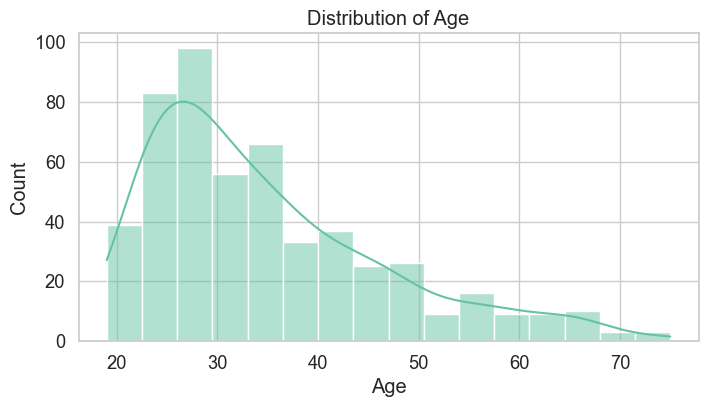

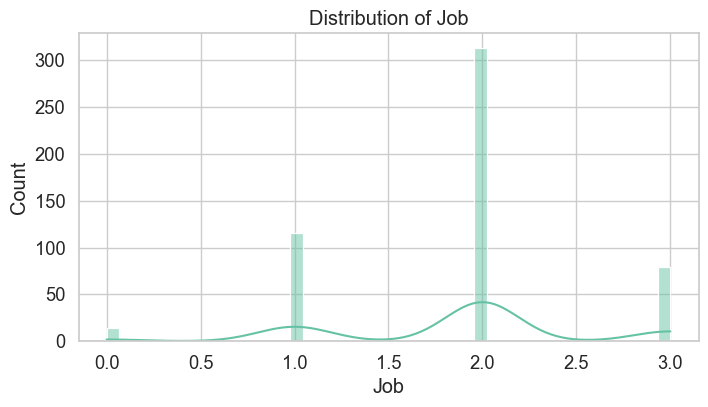

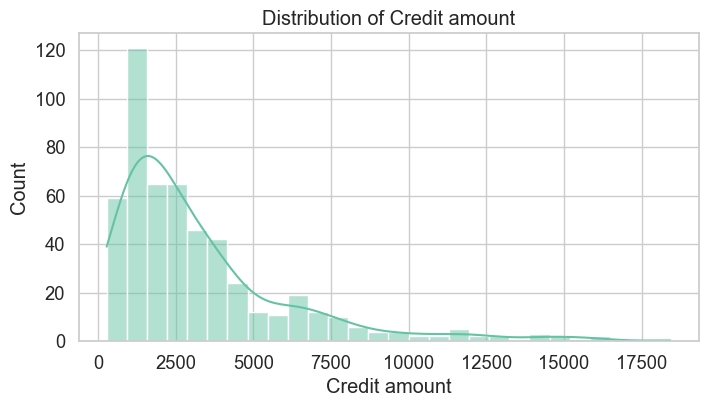

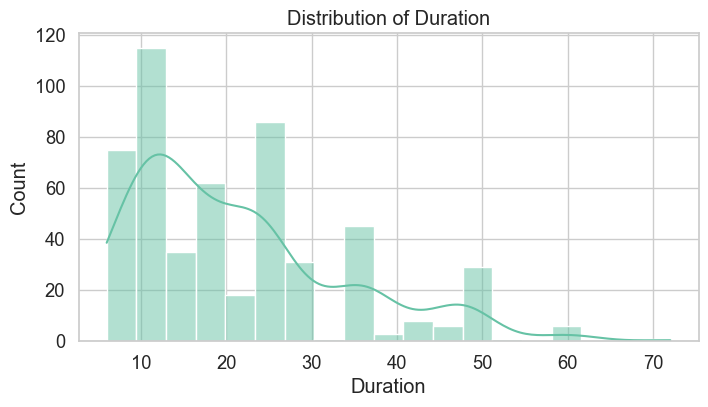

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(wd[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

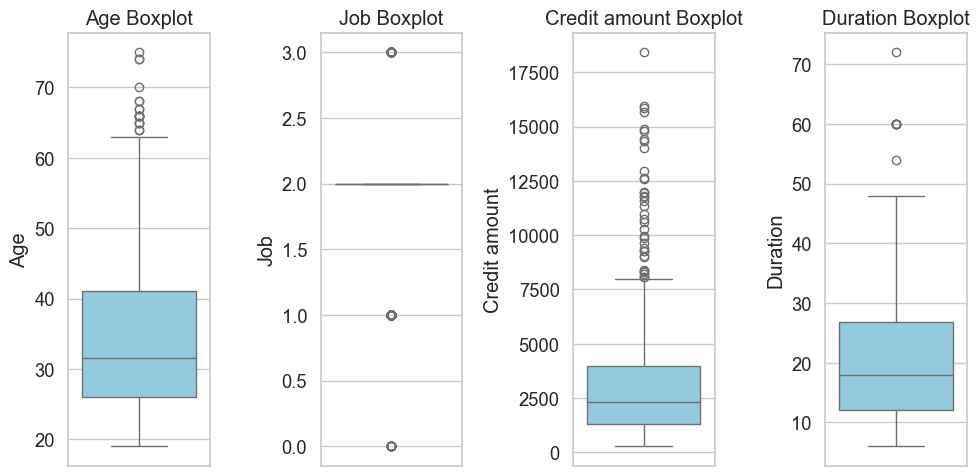

In [13]:
plt.figure(figsize=(10,5))
for i , col in enumerate(numeric_cols):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=wd[col], color='skyblue')
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

In [14]:
# here we can see that there are some outliers in the credit amount and duration columns but i will not drop them because they are important for the model and they are not many
wd[wd["Duration"]>50]


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
95,58,male,2,rent,little,moderate,15945,54,business,bad
332,24,female,3,own,moderate,moderate,7408,60,car,bad
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
714,27,male,3,own,little,moderate,14027,60,car,bad
938,42,male,2,free,little,moderate,6288,60,education,bad
973,36,male,2,rent,little,little,7297,60,business,bad


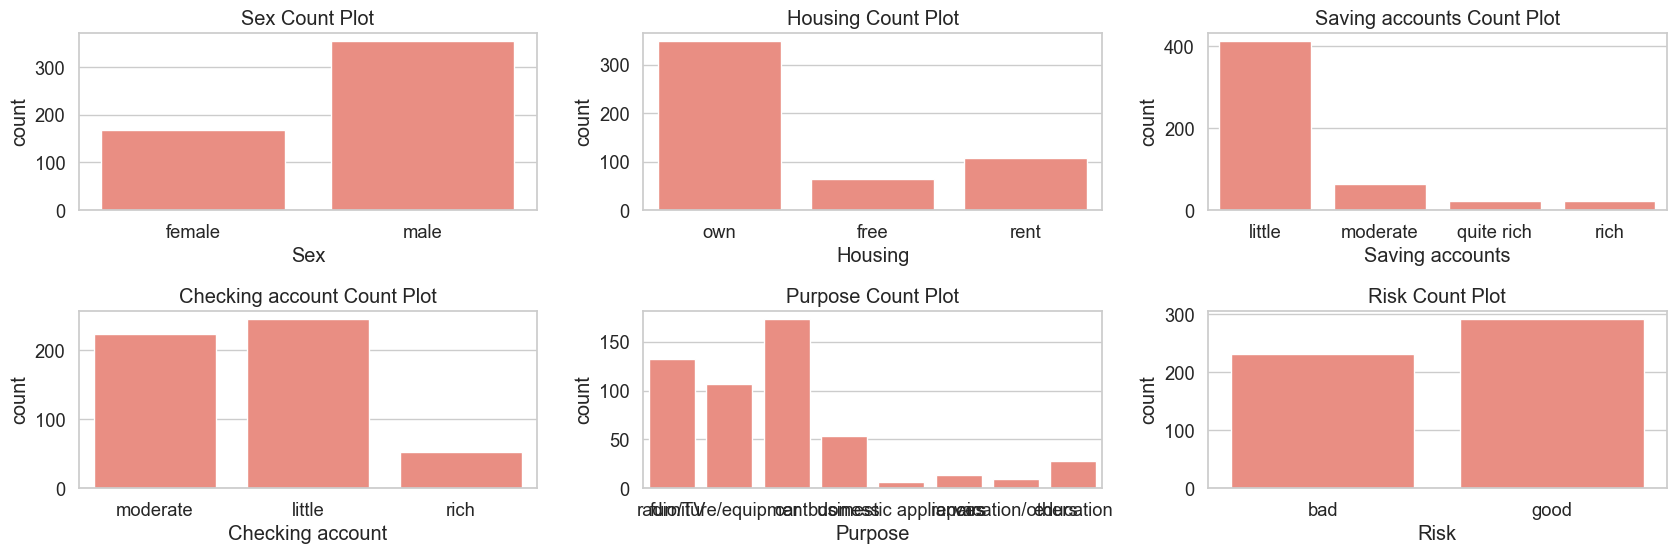

In [15]:
plt.figure(figsize=(17,8))
for i , col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(x=wd[col], color='salmon')
    plt.title(f'{col} Count Plot')
plt.tight_layout()
plt.show()

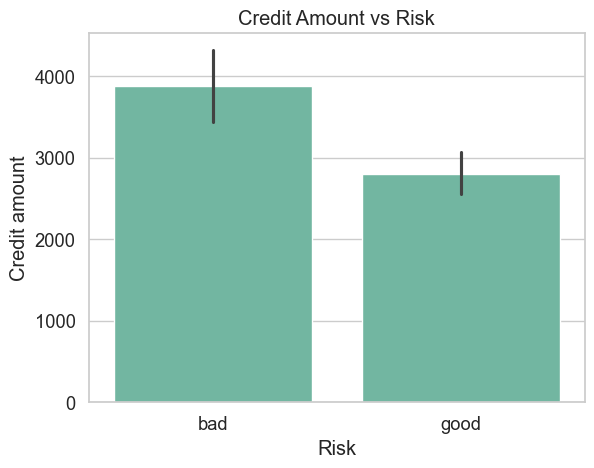

In [16]:
sns.barplot(y=wd['Credit amount'], x=wd['Risk'])
plt.title('Credit Amount vs Risk')
plt.show()

Text(0.5, 1.0, 'Duration Distribution by Risk')

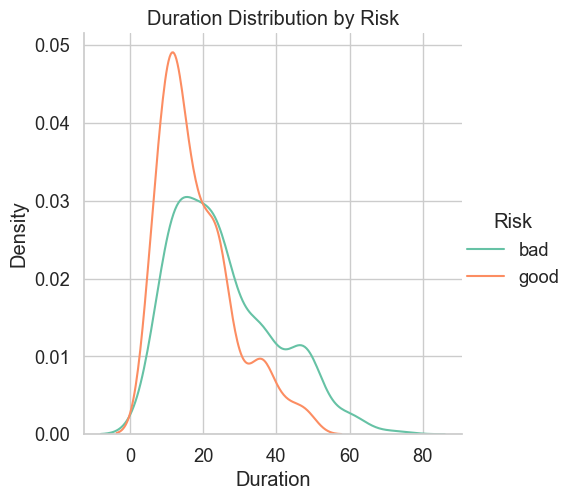

In [17]:
sns.FacetGrid(wd, hue='Risk', height=5).map(sns.kdeplot, 'Duration').add_legend()
plt.title('Duration Distribution by Risk')

Text(0.5, 1.0, 'Correlation Heatmap')

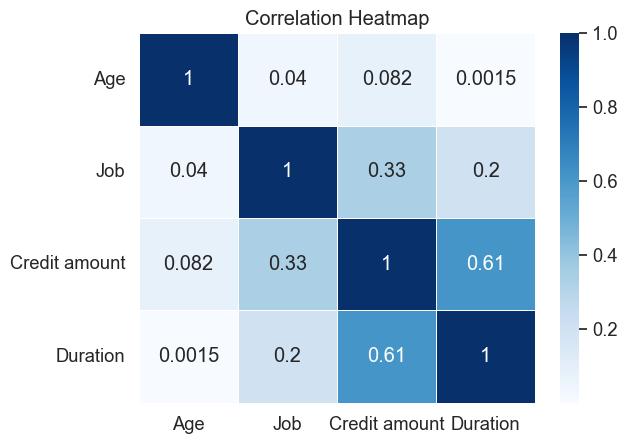

In [18]:
numeric_cols = wd.select_dtypes(include='number').columns
sns.heatmap(wd[numeric_cols].corr(), annot=True, cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap')

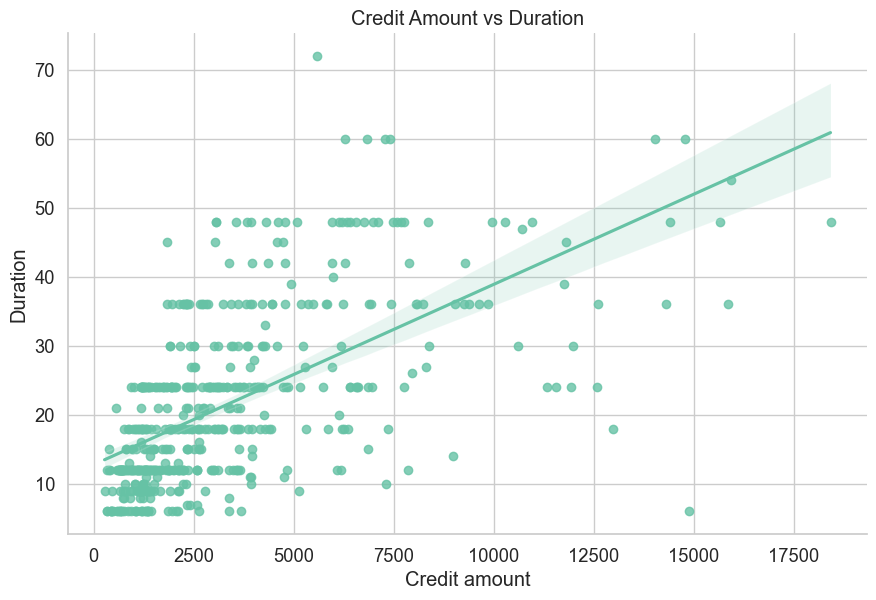

In [19]:
sns.lmplot(data=wd, x='Credit amount', y='Duration', palette='Set1', height=6, aspect=1.5)
plt.title('Credit Amount vs Duration')
plt.show()

In [20]:
wd.groupby('Job')['Credit amount'].mean().sort_values(ascending=False)

Job
3    5648.784810
2    3129.130990
1    2250.715517
0    1767.857143
Name: Credit amount, dtype: float64

In [46]:
v=wd['Risk'].value_counts(normalize=True)*100
for i in v.index:
    print(f'{i}: {v[i]:.2f}% ')  
print('\n##################')
print(' data is balanced and it is good for modeling')
print('##################')
    
    

good: 55.75% 
bad: 44.25% 

##################
 data is balanced and it is good for modeling
##################


In [22]:
df_model=wd.copy()
for col in df_model:
    print(col, df_model[col].unique()[:10],'\n')

Age [22 45 53 35 28 25 24 60 32 44] 

Sex <StringArray>
['female', 'male']
Length: 2, dtype: str 

Job [2 3 1 0] 

Housing <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str 

Saving accounts <StringArray>
['little', 'moderate', 'quite rich', 'rich']
Length: 4, dtype: str 

Checking account <StringArray>
['moderate', 'little', 'rich']
Length: 3, dtype: str 

Credit amount [5951 7882 4870 6948 5234 1295 4308 1567 1199 1403] 

Duration [48 42 24 36 30 12 15  6 10  7] 

Purpose <StringArray>
[           'radio/TV', 'furniture/equipment',                 'car',
            'business', 'domestic appliances',             'repairs',
     'vacation/others',           'education']
Length: 8, dtype: str 

Risk <StringArray>
['bad', 'good']
Length: 2, dtype: str 



In [23]:
for col in df_model[categorical_cols]:
    print(col, df_model[col].unique()[:10],'\n')

Sex <StringArray>
['female', 'male']
Length: 2, dtype: str 

Housing <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str 

Saving accounts <StringArray>
['little', 'moderate', 'quite rich', 'rich']
Length: 4, dtype: str 

Checking account <StringArray>
['moderate', 'little', 'rich']
Length: 3, dtype: str 

Purpose <StringArray>
[           'radio/TV', 'furniture/equipment',                 'car',
            'business', 'domestic appliances',             'repairs',
     'vacation/others',           'education']
Length: 8, dtype: str 

Risk <StringArray>
['bad', 'good']
Length: 2, dtype: str 



In [47]:

## buliding model & peocessing

In [48]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
7,35,male,3,rent,little,moderate,6948,36,car,good
9,28,male,3,own,little,moderate,5234,30,car,bad


In [25]:
#base line model (logistic regression)
df_1=df_model.copy()
#encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()



df_1['Risk']=df_model['Risk'].apply(lambda x : 1 if x=='good' else 0)
lab_cols=['Sex','Housing','Saving accounts','Checking account']
df_1[lab_cols]=df_1[lab_cols].apply(le.fit_transform)
df_1=pd.get_dummies(df_1, columns=['Purpose','Job'], drop_first=True)
df_1.head()

#splitting data
from sklearn.model_selection import train_test_split
x=df_1.drop('Risk', axis=1)
y=df_1['Risk']
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)


#scaling (based on data distribution i will use standard scaler)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_cols=['Duration','Credit amount','Age']
x_train[scale_cols]=scaler.fit_transform(x_train[scale_cols])
x_test[scale_cols]=scaler.transform(x_test[scale_cols])


Accuracy Score:
0.5619047619047619
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.50      0.52        50
           1       0.58      0.62      0.60        55

    accuracy                           0.56       105
   macro avg       0.56      0.56      0.56       105
weighted avg       0.56      0.56      0.56       105

Confusion Matrix:
[[25 25]
 [21 34]]


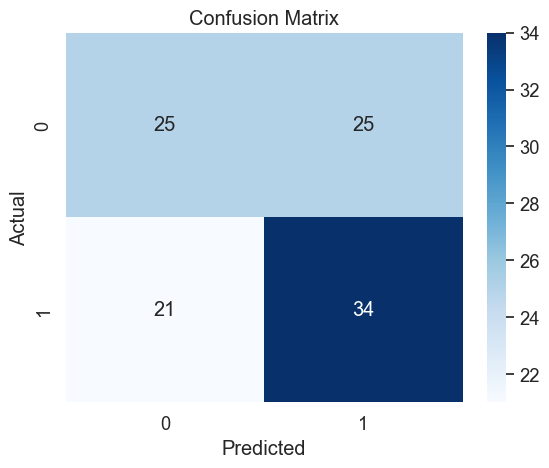

In [26]:
#making the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,auc, roc_curve

logr=LogisticRegression()

logr.fit(x_train,y_train)

y_pred=logr.predict(x_test)

#evalution the model
print('Accuracy Score:')
print(accuracy_score(y_test,y_pred)) 
print('Classification Report:')
print(classification_report(y_test,y_pred)) 
print('Confusion Matrix:')
print(confusion_matrix(y_test,y_pred)) 

conv_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conv_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

AUC Score:
0.5978181818181818


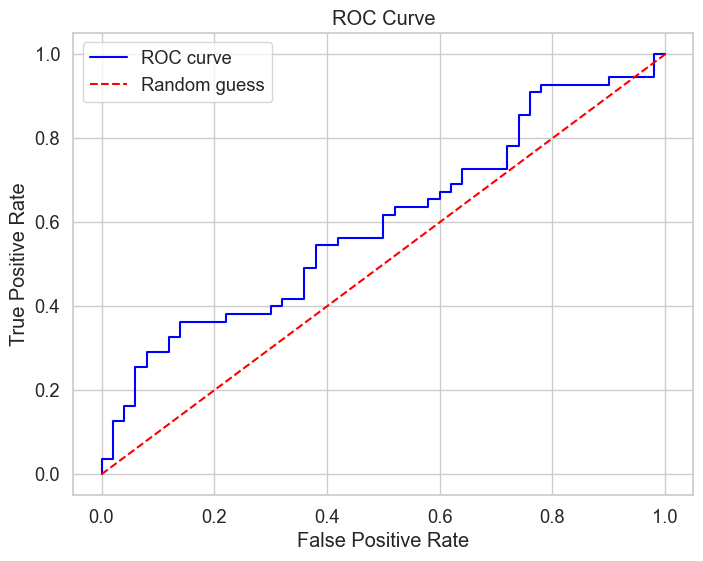

In [27]:
#makeing roc curve and auc(must use the predict_proba)
y_prob=logr.predict_proba(x_test)[:,1]
fpr, tpr, thresholds=roc_curve(y_test,y_prob)   
#draw the roc curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()


auc_score=auc(fpr, tpr)
print('AUC Score:')
print(auc_score)


In [28]:
#modle is bad the curve is close to the random guess line and the auc score is low (0.59) so i need to do some feature engineering and try other models to improve the performance of the model

In [29]:
features=wd.columns.drop(['Purpose'])
features

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Risk'],
      dtype='str')

In [30]:
models=wd[features]
models.info()

<class 'pandas.DataFrame'>
Index: 522 entries, 1 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               522 non-null    int64
 1   Sex               522 non-null    str  
 2   Job               522 non-null    int64
 3   Housing           522 non-null    str  
 4   Saving accounts   522 non-null    str  
 5   Checking account  522 non-null    str  
 6   Credit amount     522 non-null    int64
 7   Duration          522 non-null    int64
 8   Risk              522 non-null    str  
dtypes: int64(4), str(5)
memory usage: 40.8 KB


In [31]:
#splitting data

from sklearn.model_selection import train_test_split
x=models.drop('Risk', axis=1)
y=models['Risk']
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,stratify=y ,random_state=42)
cat_columns=x_train.select_dtypes(include='object').columns





In [32]:
print(cat_columns)

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')


In [33]:
from sklearn.preprocessing import LabelEncoder

os.makedirs('encoders', exist_ok=True)

le_diect={}
for col in cat_columns:
    le=LabelEncoder()
    x_train[col]=le.fit_transform(x_train[col])
    x_test[col]=le.transform(x_test[col])
    le_diect[col]=le
    joblib.dump(le, f'encoders/{col}_encoder.pkl')

In [34]:
# encode the target variable
le_target=LabelEncoder()
y_train=le_target.fit_transform(y_train)
y_test=le_target.transform(y_test)
joblib.dump(le_target, 'encoders/target_encoder.pkl')

['encoders/target_encoder.pkl']

In [35]:
x_train

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
818,43,1,3,1,0,0,15857,36
179,65,1,2,1,0,0,571,21
966,23,1,1,1,2,1,2520,27
872,26,1,2,1,1,0,1382,24
660,23,1,2,2,0,2,1297,12
...,...,...,...,...,...,...,...,...
805,24,1,2,1,0,0,9271,36
187,68,1,0,0,0,1,1175,16
23,44,1,2,1,1,1,1804,12
340,24,0,2,0,0,1,5743,24


In [36]:
# we will use tree based models so we will not scale the data because tree based models are not affected by the scale 


In [37]:
from sklearn.ensemble import RandomForestClassifier ,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,auc, roc_curve

In [38]:
def train_model (model,param_grid,x_train,x_test,y_train,y_test):
    ''' train your model '''
    grid=GridSearchCV(model,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
    grid.fit(x_train,y_train)  
    best_par=grid.best_params_
    best_model=grid.best_estimator_
    y_pred =best_model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    conv=confusion_matrix(y_test,y_pred)
    report=classification_report(y_test,y_pred)
  
    return best_model,acc,best_par,conv,report



In [39]:
#null accurcy model 
overall=len(y_test)+len(y_train)
ones=list(y_test).count(1)+list(y_train).count(1)
zeros=list(y_test).count(0)+list(y_train).count(0)

null_acc=max (ones,zeros)/overall
print(f"Null Accurcy model gives :{null_acc} ")



Null Accurcy model gives :0.5574712643678161 


best_Rf score :0.6285714285714286 

best parametar:{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200} 

              precision    recall  f1-score   support

           0       0.57      0.59      0.58        46
           1       0.67      0.66      0.67        59

    accuracy                           0.63       105
   macro avg       0.62      0.62      0.62       105
weighted avg       0.63      0.63      0.63       105
 



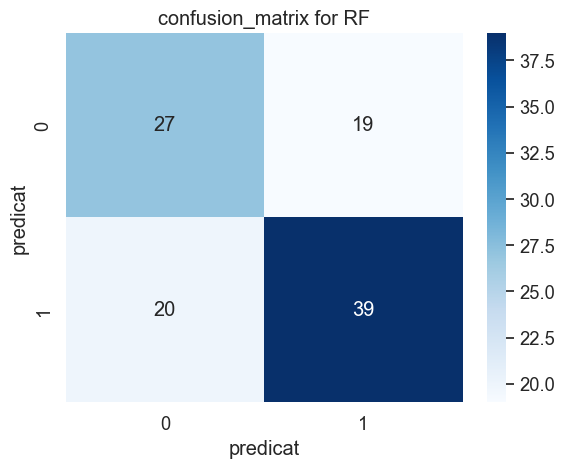

In [ ]:
# start with Randomforst
Rf=RandomForestClassifier(random_state=42,class_weight='balanced')

Rf_parametars={
    'n_estimators':[100,200],
    'max_depth':[5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]    
}

best_Rf,acc_Rf,best_par_Rf,conv, report=train_model(Rf,Rf_parametars,x_train,x_test,y_train,y_test)

print(f'best_Rf score :{acc_Rf}','\n')
print(f'best parametar:{best_par_Rf}','\n')
print(f'{report}','\n')

sns.heatmap(data=conv, annot=True,cmap='Blues')
plt.title(f'confusion_matrix for RF')
plt.xlabel('Acctual')
plt.ylabel('predicat')
plt.show() 


best_ET score : 0.6285714285714286

best parameter : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

              precision    recall  f1-score   support

           0       0.56      0.67      0.61        46
           1       0.70      0.59      0.64        59

    accuracy                           0.63       105
   macro avg       0.63      0.63      0.63       105
weighted avg       0.64      0.63      0.63       105




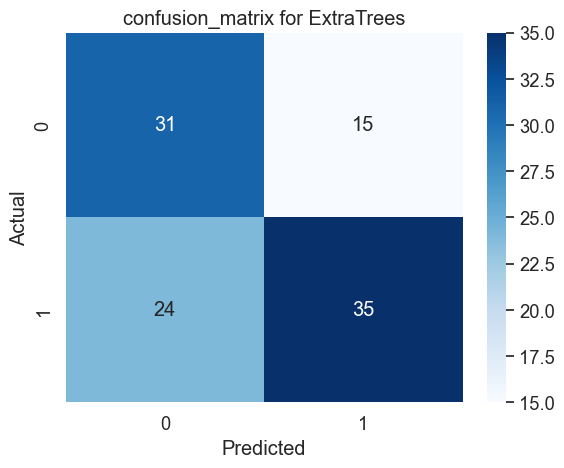

In [57]:
# start with ExtraTrees

Et = ExtraTreesClassifier(
    random_state=42,
    class_weight='balanced'
)

Et_parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_Et, acc_Et, best_par_Et, conv, report = train_model(
    Et,
    Et_parameters,
    x_train,
    x_test,
    y_train,
    y_test
)

print(f'best_ET score : {acc_Et}\n')

print(f'best parameter : {best_par_Et}\n')

print(f'{report}\n')

sns.heatmap(data=conv, annot=True, cmap='Blues')

plt.title('confusion_matrix for ExtraTrees')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

best_XGB score : 0.7238095238095238

best parameter : {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}

              precision    recall  f1-score   support

           0       0.70      0.65      0.67        46
           1       0.74      0.78      0.76        59

    accuracy                           0.72       105
   macro avg       0.72      0.72      0.72       105
weighted avg       0.72      0.72      0.72       105




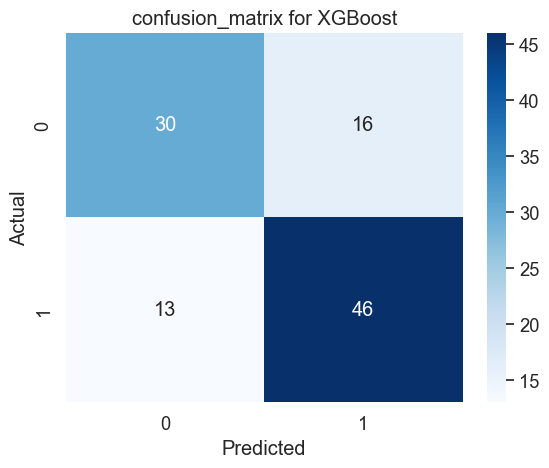

In [40]:
# start with XGBoost

Xgb = XGBClassifier(
    random_state=42,
)

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

best_Xgb, acc_Xgb, best_par_Xgb, conv, report = train_model(
    Xgb,
    xgb_param_grid,
    x_train,
    x_test,
    y_train,
    y_test
)

print(f'best_XGB score : {acc_Xgb}\n')

print(f'best parameter : {best_par_Xgb}\n')

print(f'{report}\n')

sns.heatmap(data=conv, annot=True, cmap='Blues')

plt.title('confusion_matrix for XGBoost')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

best_SVC score : 0.6190476190476191

best parameter : {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}

              precision    recall  f1-score   support

           0       0.58      0.48      0.52        46
           1       0.64      0.73      0.68        59

    accuracy                           0.62       105
   macro avg       0.61      0.60      0.60       105
weighted avg       0.61      0.62      0.61       105




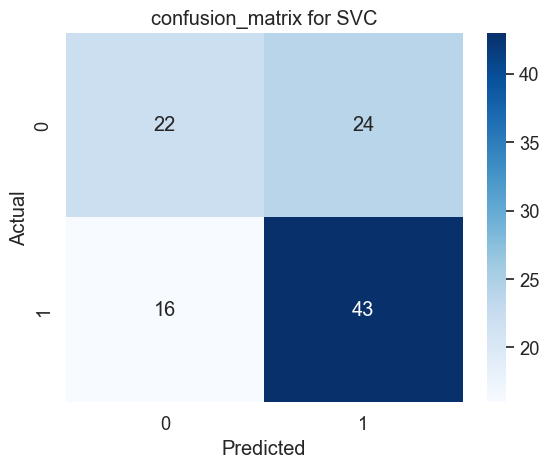

In [62]:
# make scaling for svc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe1 = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

params = [
    {
        'svc__C': [1, 10, 100],
        'svc__kernel': ['linear']
    },
    {
        'svc__C': [1, 10, 100],
        'svc__kernel': ['poly'],
        'svc__degree': [2, 3, 4]
    },
    {
        'svc__C': [1, 10, 100],
        'svc__kernel': ['rbf'],
        'svc__gamma': [0.01, 0.1, 0.2]
    }
]

best_svc, acc_svc, best_par_svc, conv, report = train_model(
    pipe1,
    params,
    x_train,
    x_test,
    y_train,
    y_test
)

print(f'best_SVC score : {acc_svc}\n')

print(f'best parameter : {best_par_svc}\n')

print(f'{report}\n')

sns.heatmap(data=conv, annot=True, cmap='Blues')

plt.title('confusion_matrix for SVC')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()



In [50]:
#saving the bast accurcy model
joblib.dump(best_Xgb,'D:\Data analysis\ml\here you go\my work\logistic project\models\Xgb_model.pkl')

['D:\\Data analysis\\ml\\here you go\\my work\\logistic project\\models\\Xgb_model.pkl']